# Prose authors with esTS

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/esTS/blob/master/examples/02_prose_authors.ipynb)

The ten prose writers with at least three works in the corpus of Spanish-language literature - Galdós, Blasco Ibáñez, Palacio Valdés, Pardo Bazán, Pereda, Unamuno, Valera, Valle-Inclán, Clarín and Payró - compared with each other: distances between their works by the most frequent words (Burrows's and Cosine Delta), the clustering of the works, the attribution of works held out from the profiles of the authors, the words that one author prefers and another avoids (Zeta), the features of the text that tell two authors apart and the lengths of their words. Every section links to the page of the [documentation](https://sergeyshk.github.io/esTS/) with all the statistics and parameters.

## Installation

In Colab the cell installs the library and the spaCy model `es_core_news_sm`; where they are installed it does nothing.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ests") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyests"], check=True)
if importlib.util.find_spec("es_core_news_sm") is None:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "es_core_news_sm", "-q"], check=True
    )

## The corpus

The [corpus of Spanish-language literature](https://sergeyshk.github.io/esTS/datasets/spanishliterature/) holds 107 works of prose, the transcriptions of Project Gutenberg. The notebook takes the authors with at least three of them, so that every author keeps at least two works when one is held out for the attribution. The words are counted here by the spaces, which is enough for the size of a work.

In [2]:
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

from ests import WordsExtractor
from ests.corpus import (
    compare_corpora,
    delta,
    delta_profiles,
    frequency_table,
    kilgarriff_chi2,
    mendenhall_distance,
    split_windows,
    zeta,
)
from ests.datasets import SpanishLiterature
from ests.visualizers import dendrogram_plot, mds_plot, mendenhall_plot

sl = SpanishLiterature()
sl.download()
records = list(sl.get_records(genre="prose"))
n_works = Counter(record["author"] for record in records)
authors = [author for author, count in n_works.most_common() if count >= 3]
# The works of an author stay in the order of the years
records = sorted(
    (record for record in records if record["author"] in authors),
    key=lambda record: authors.index(record["author"]),
)
SHORT_NAMES = {
    "Benito Pérez Galdós": "Galdós",
    "Vicente Blasco Ibáñez": "Blasco Ibáñez",
    "Armando Palacio Valdés": "Palacio Valdés",
    "Emilia Pardo Bazán": "Pardo Bazán",
    "José María de Pereda": "Pereda",
    "Miguel de Unamuno": "Unamuno",
    "Juan Valera": "Valera",
    "Ramón del Valle-Inclán": "Valle-Inclán",
    "Leopoldo Alas «Clarín»": "Clarín",
    "Roberto J. Payró": "Payró",
}

rows = {}
for author in authors:
    own = [record for record in records if record["author"] == author]
    years = [record["year_from"] for record in own]
    rows[SHORT_NAMES[author]] = {
        "works": len(own),
        "years": f"{min(years)}-{max(years)}",
        "words, thousands": round(sum(len(record["text"].split()) for record in own) / 1000),
    }
corpus_table = pd.DataFrame(rows).T
print(f"{len(authors)} authors, {len(records)} works")
corpus_table

10 authors, 93 works


,works,years,"words, thousands"
Galdós,21,1870-1897,2010
Blasco Ibáñez,15,1894-1919,1606
Palacio Valdés,13,1881-1906,1192
Pardo Bazán,13,1881-1911,915
Pereda,8,1864-1895,785
Unamuno,6,1902-1921,237
Valera,6,1874-1897,424
Valle-Inclán,5,1902-1926,147
Clarín,3,1884-1893,442
Payró,3,1906-1910,164


Ten authors pass the threshold, with 93 works and 7.9 million words together. Galdós alone has 21 works and two million words, Valle-Inclán five works and 147 thousand words. The years of the first publication run from 1864 (Pereda) to 1926 (Valle-Inclán); all the authors are Spanish except the Argentine Roberto J. Payró.

### The spelling of the editions

The texts keep the spelling of their editions, and the [dataset page](https://sergeyshk.github.io/esTS/datasets/spanishliterature/) warns that some have the accents of their time on monosyllables: the prepositions and conjunctions `á`, `é`, `ó`, `ú` and the verbs `fué`, `dió`, `vió`. For a frequency list `á` and `a` are different words, so stylometry could separate the works by their edition instead of their author, and the spaCy model, trained on the modern spelling, may tag them wrongly. Following the page, the notebook removes these accents; the list below adds `fuí`, `dí`, `ví`, `tí` and `pié`, found in the same editions. A work counts as having the old accents when they occur at least once per 1000 words.

In [3]:
OLD_MONOSYLLABLES = {
    "á": "a",
    "é": "e",
    "ó": "o",
    "ú": "u",
    "fué": "fue",
    "fuí": "fui",
    "dió": "dio",
    "vió": "vio",
    "dí": "di",
    "ví": "vi",
    "tí": "ti",
    "pié": "pie",
}
OLD_PATTERN = re.compile(r"\b(?:" + "|".join(OLD_MONOSYLLABLES) + r")\b", re.IGNORECASE)


def modernize(text):
    """Removing the old accents of the monosyllables, keeping a capital letter"""

    def replace(match):
        word = match.group()
        modern = OLD_MONOSYLLABLES[word.lower()]
        return modern.capitalize() if word[0].isupper() else modern

    return OLD_PATTERN.sub(replace, text)


def has_old_accents(text):
    """At least one old accented monosyllable per 1000 words"""
    return len(OLD_PATTERN.findall(text)) * 1000 >= len(text.split())


print(modernize("Fué á Madrid y le dió un libro ó dos."))
corpus_table["old accents"] = [
    sum(has_old_accents(record["text"]) for record in records if record["author"] == author)
    for author in authors
]
corpus_table

Fue a Madrid y le dio un libro o dos.


,works,years,"words, thousands",old accents
Galdós,21,1870-1897,2010,13
Blasco Ibáñez,15,1894-1919,1606,7
Palacio Valdés,13,1881-1906,1192,6
Pardo Bazán,13,1881-1911,915,9
Pereda,8,1864-1895,785,7
Unamuno,6,1902-1921,237,6
Valera,6,1874-1897,424,2
Valle-Inclán,5,1902-1926,147,3
Clarín,3,1884-1893,442,1
Payró,3,1906-1910,164,3


The function turns the old spelling of the example into the modern one. 57 of the 93 works have the old accents, and so does at least one work of every author: all the works of Unamuno and Payró, 13 of the 21 of Galdós, one of the three of Clarín. Most authors thus mix both spellings - the case where the accents could pull the works of one author apart.

### The sample

A whole novel is not needed for stylometry, and the ten authors have almost eight million words, so every work is represented by a fixed sample: the first ten windows of about 1000 words of its first 100,000 characters, cut by [`split_windows`](https://sergeyshk.github.io/esTS/corpus/compare/). The whitespace is collapsed, as the page of the comparison of corpora advises for texts from different editions, and the old accents are removed. [`WordsExtractor`](https://sergeyshk.github.io/esTS/extractors/words/) gives the lower-case words of every window; the words of the original spelling are kept as well for the comparison below.

In [4]:
N_WINDOWS = 10
OPENING = 100_000  # characters, more than ten windows of 1000 words

we = WordsExtractor(lowercase=True)
works = {}
for record in records:
    opening = re.sub(r"[^\S\n]+", " ", record["text"][:OPENING])
    windows = split_windows(opening, window=1000)[:N_WINDOWS]
    modern = [modernize(window) for window in windows]
    works[f"{SHORT_NAMES[record['author']]}: {record['title']}"] = {
        "author": SHORT_NAMES[record["author"]],
        "title": record["title"],
        "year": record["year_from"],
        "old": has_old_accents("\n".join(windows)),
        "windows": modern,
        "window_words": [list(we.extract(window)) for window in modern],
        "raw_words": list(we.extract("\n".join(windows))),
    }
for work in works.values():
    work["words"] = [word for words in work["window_words"] for word in words]

sizes = pd.Series({name: len(work["words"]) for name, work in works.items()})
print(f"{len(works)} works, {sum(len(work['windows']) for work in works.values())} windows")
print(f"words per sample: {sizes.min()} to {sizes.max()}, {sizes.sum()} in all")
print(f"samples with the old accents: {sum(work['old'] for work in works.values())}")

93 works, 930 windows
words per sample: 9738 to 10295, 932404 in all
samples with the old accents: 57


The 93 samples hold 930 windows and 932,404 words, from 9738 to 10,295 per work, so every work weighs about the same in what follows whatever its length. 57 samples have the old accents, as many as the whole works.

## Stylometry

[Stylometry](https://sergeyshk.github.io/esTS/corpus/stylometry/) compares texts by the relative frequencies of their most frequent words (MFW): mostly function words, which an author uses without thinking about them. [`frequency_table`](https://sergeyshk.github.io/esTS/corpus/stylometry/#delta) gives the frequencies, [`delta`](https://sergeyshk.github.io/esTS/corpus/stylometry/#delta) turns their z-scores into distances between texts (Burrows's Delta, the mean absolute difference of the z-scores, and Cosine Delta, one minus their cosine similarity), and the [plots](https://sergeyshk.github.io/esTS/visualizers/stylometry/) draw the distances.

### The most frequent words

The profile of an author is here all the words of the samples of their works put together. The table gives the twelve most frequent words of the ten profiles, in percent of all the words.

In [5]:
profiles = {SHORT_NAMES[author]: [] for author in authors}
for work in works.values():
    profiles[work["author"]].extend(work["words"])
(frequency_table(profiles, n_mfw=12) * 100).round(2)

,de,y,la,que,el,en,a,los,no,se,con,las
Galdós,5.60,3.47,3.45,3.67,2.22,2.24,2.15,1.31,1.62,1.17,1.19,1.05
Blasco Ibáñez,6.47,2.94,3.86,2.70,2.83,2.45,2.17,2.12,0.71,0.92,1.57,1.52
Palacio Valdés,5.23,3.35,3.59,3.06,2.31,2.32,2.51,1.47,1.50,1.50,1.34,1.03
Pardo Bazán,5.72,3.74,3.97,2.96,2.75,2.17,2.40,1.28,1.44,1.32,1.05,1.09
Pereda,6.05,4.37,3.61,3.71,2.69,2.50,2.39,1.41,1.26,1.20,1.14,1.04
Unamuno,4.71,3.97,3.01,3.78,2.09,1.81,2.54,0.99,2.28,1.31,0.89,0.63
Valera,5.65,4.93,2.98,3.66,2.17,2.61,2.45,1.21,1.43,1.27,1.18,0.96
Valle-Inclán,5.60,3.81,4.17,2.13,3.12,2.47,1.49,2.07,0.76,1.19,1.30,1.72
Clarín,6.07,3.23,3.98,3.15,2.67,2.74,2.30,1.69,1.32,1.40,1.00,1.05
Payró,5.15,4.07,3.23,3.16,2.40,2.24,2.23,1.32,1.62,1.16,1.05,0.96


The same words lead every profile - *de*, *y*, *la*, *que*, *el*, *en*, *a* - in different proportions. Unamuno has the fewest *de* (4.71%) and *las* (0.63%) and the most *no* (2.28%) and *que* (3.78%); Valle-Inclán has the fewest *que* (2.13%) and *a* (1.49%) and the most *la*, *el* and *las*; Blasco Ibáñez has the most *de* (6.47%) and *los* and the fewest *no* (0.71%). Delta turns such differences over hundreds of words into one distance.

### Spelling, Delta and the nearest work

A simple check of whether the works group by author: for every work, find the nearest other work by Delta and see whether it is by the same author. The same check tells whether the nearest work has the same spelling (old or modern accents). The table runs it for both variants of Delta, three numbers of the most frequent words and both spellings of the samples - the original one and the one without the old accents; each share is out of all the works.

In [6]:
def nearest(distances):
    """The nearest other text for every text of a matrix of distances"""
    return distances.apply(lambda row: row.drop(row.name).idxmin(), axis=1)


checks = []
for variant in ("burrows", "cosine"):
    for n_mfw in (100, 200, 500):
        check = {"variant": variant, "MFW": n_mfw}
        for spelling, key in (("original", "raw_words"), ("modern", "words")):
            distances = delta(
                {name: work[key] for name, work in works.items()}, n_mfw=n_mfw, variant=variant
            )
            pairs = [(works[name], works[other]) for name, other in nearest(distances).items()]
            check[f"same author, {spelling}"] = sum(a["author"] == b["author"] for a, b in pairs)
            check[f"same spelling, {spelling}"] = sum(a["old"] == b["old"] for a, b in pairs)
        checks.append(check)
n_old = sum(work["old"] for work in works.values())
n_modern = len(works) - n_old
chance = (n_old * (n_old - 1) + n_modern * (n_modern - 1)) / (len(works) * (len(works) - 1))
print(f"two works taken at random share the spelling with probability {chance:.3f}")
(pd.DataFrame(checks).set_index(["variant", "MFW"]) / len(works)).round(3)

two works taken at random share the spelling with probability 0.520


same author, original  same spelling, original  \
variant MFW                                                   
burrows 100                  0.796                    0.688   
        200                  0.882                    0.731   
        500                  0.871                    0.645   
cosine  100                  0.849                    0.710   
        200                  0.914                    0.645   
        500                  0.914                    0.731   

             same author, modern  same spelling, modern  
variant MFW                                              
burrows 100                0.871                  0.527  
        200                0.882                  0.538  
        500                0.839                  0.516  
cosine  100                0.882                  0.548  
        200                0.914                  0.581  
        500                0.925                  0.602

With the modern spelling and Cosine Delta over 200 and 500 words, the nearest work is by the same author for 0.914 and 0.925 of the works, and Cosine Delta is at least as good as Burrows's at every number of words. Removing the accents helps most with few words: at 100 words the share of the same author rises from 0.796 to 0.871 (Burrows) and from 0.849 to 0.882 (Cosine); at 200 it does not change, and with Burrows at 500 it falls from 0.871 to 0.839. The last columns show what the accents did: with the original spelling the nearest work has the same spelling in 0.645-0.731 of the cases, with the modern one in 0.516-0.602, close to the 0.520 of two works taken at random. The rest above chance is expected, since some authors have all their works in one spelling (Unamuno, Payró).

### Clustering the works

A [dendrogram](https://sergeyshk.github.io/esTS/visualizers/stylometry/#dendrogram_plot) of the first three works of every author (by year), thirty texts, by Cosine Delta over the 200 most frequent words of the modern spelling; the clustering is Ward's method, as in [Evert et al. (2015)](https://aclanthology.org/W15-0709.pdf).

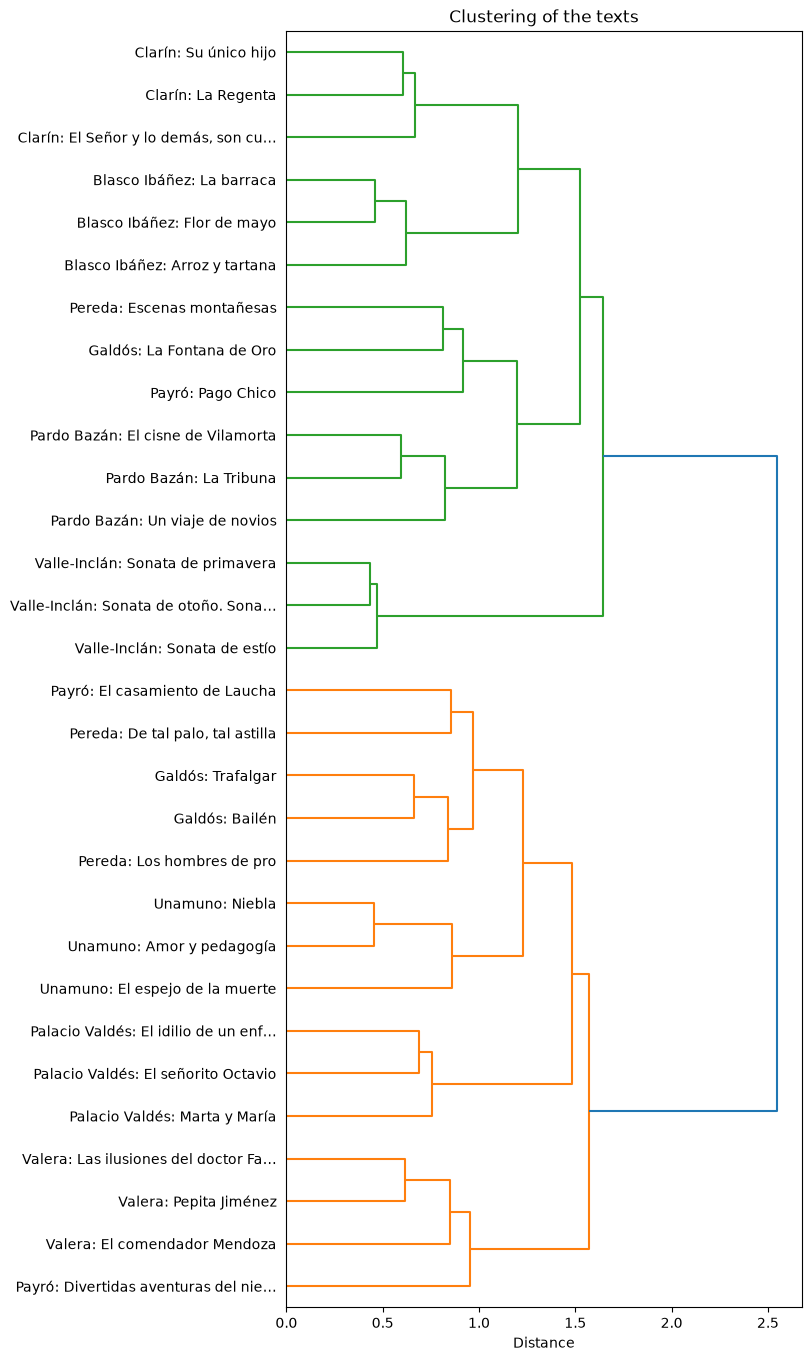

In [7]:
first_works = defaultdict(list)
for name, work in works.items():
    if len(first_works[work["author"]]) < 3:
        first_works[work["author"]].append(name)
subset = {
    name if len(name) <= 36 else name[:35] + "…": works[name]["words"]
    for names in first_works.values()
    for name in names
}
dendrogram_plot(delta(subset, n_mfw=200, variant="cosine"))
plt.show()

Seven of the ten authors have their three works joined into a cluster of their own before anything else joins it: Clarín, Blasco Ibáñez, Pardo Bazán, Valle-Inclán, Unamuno, Palacio Valdés and Valera. Galdós, Pereda and Payró mix: *La Fontana de Oro* joins *Escenas montañesas* of Pereda, *Trafalgar* and *Bailén* join *Los hombres de pro*, and the three works of Payró fall into three different branches. The first split of the tree puts Clarín, Blasco Ibáñez, Pardo Bazán and Valle-Inclán on one side and Unamuno, Palacio Valdés and Valera on the other.

### Distances between the authors

Cosine Delta over the 200 most frequent words between the ten profiles, and their [multidimensional scaling](https://sergeyshk.github.io/esTS/visualizers/stylometry/#mds_plot) on a plane. The profiles differ in size, from three to 21 works, which Delta allows: it compares relative frequencies.

,Galdós,Blasco Ibáñez,Palacio Valdés,Pardo Bazán,Pereda,Unamuno,Valera,Valle-Inclán,Clarín,Payró
Galdós,0.00,1.35,0.95,1.07,0.83,0.83,1.10,1.20,1.36,0.96
Blasco Ibáñez,1.35,0.00,1.07,1.12,1.23,1.42,1.20,0.75,0.76,1.27
Palacio Valdés,0.95,1.07,0.00,1.04,1.02,1.17,1.11,1.11,1.14,1.02
Pardo Bazán,1.07,1.12,1.04,0.00,1.04,1.11,1.22,0.71,1.20,1.20
Pereda,0.83,1.23,1.02,1.04,0.00,1.09,1.04,1.29,1.09,1.07
Unamuno,0.83,1.42,1.17,1.11,1.09,0.00,1.05,1.31,1.27,1.00
Valera,1.10,1.20,1.11,1.22,1.04,1.05,0.00,1.40,0.97,0.97
Valle-Inclán,1.20,0.75,1.11,0.71,1.29,1.31,1.40,0.00,1.19,1.21
Clarín,1.36,0.76,1.14,1.20,1.09,1.27,0.97,1.19,0.00,1.22
Payró,0.96,1.27,1.02,1.20,1.07,1.00,0.97,1.21,1.22,0.00


Galdós: nearest Pereda (0.83)
Blasco Ibáñez: nearest Valle-Inclán (0.75)
Palacio Valdés: nearest Galdós (0.95)
Pardo Bazán: nearest Valle-Inclán (0.71)
Pereda: nearest Galdós (0.83)
Unamuno: nearest Galdós (0.83)
Valera: nearest Clarín (0.97)
Valle-Inclán: nearest Pardo Bazán (0.71)
Clarín: nearest Blasco Ibáñez (0.76)
Payró: nearest Galdós (0.96)


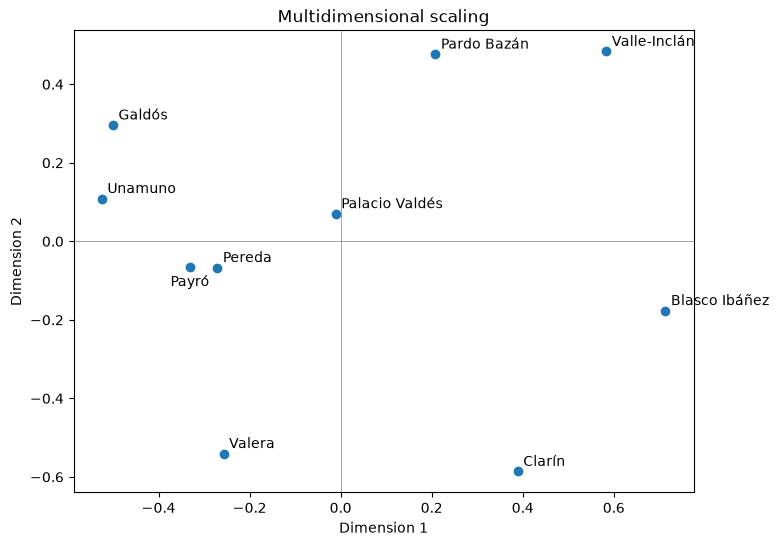

In [8]:
author_distances = delta(profiles, n_mfw=200, variant="cosine")
display(author_distances.round(2))
for author, other in nearest(author_distances).items():
    print(f"{author}: nearest {other} ({author_distances.loc[author, other]:.2f})")
fig, ax = plt.subplots(figsize=(8, 6))
mds_plot(author_distances, ax=ax)
# Payró and Pereda lie close together: the label of Payró goes under its point
payro = next(label for label in ax.texts if label.get_text() == "Payró")
payro.xyann = (0, -14)
payro.set_horizontalalignment("center")
plt.show()

The nearest profiles are Pardo Bazán and Valle-Inclán (0.71), then Blasco Ibáñez with Valle-Inclán (0.75) and with Clarín (0.76); the farthest are Unamuno and Blasco Ibáñez (1.42). Galdós is the nearest author for Palacio Valdés, Pereda, Unamuno and Payró. The first dimension of the scaling puts Blasco Ibáñez, Valle-Inclán, Clarín and Pardo Bazán at one end and Galdós, Unamuno, Pereda, Payró and Valera at the other, with Palacio Valdés in the middle - much like the first split of the dendrogram. In the table of frequencies, the first end has the most articles and the fewest *no* and *que* (Blasco Ibáñez, Valle-Inclán) and the other end the reverse (Unamuno), which suggests description on one side and dialogue and reasoning on the other.

## Attribution

The latest work of every author is held out, and the profiles of the authors are built from the other works. [`delta_profiles`](https://sergeyshk.github.io/esTS/corpus/stylometry/#delta) measures the distance from a held-out work to every profile: the most frequent words and the spread of their frequencies come from the training works only (`statistics`), so the held-out works do not influence the scale. The nearest profile is the presumed author. The settings follow the documentation rather than a search over this corpus: Cosine Delta, the variant that clusters by author best in the experiments of [Evert et al. (2015)](https://aclanthology.org/W15-0709.pdf), and 200 most frequent words, within the usual 100 to 500.

In [9]:
def attribute(test, n_mfw=200, variant="cosine"):
    """Delta from the works of test to the profiles of the authors built on the other works"""
    reference = defaultdict(list)
    statistics = {}
    for name, work in works.items():
        if name not in test:
            reference[work["author"]].extend(work["words"])
            statistics[name] = work["words"]
    samples = {name: works[name]["words"] for name in test}
    return delta_profiles(reference, samples, n_mfw=n_mfw, variant=variant, statistics=statistics)


latest = {work["author"]: name for name, work in works.items()}
distances = attribute([latest[author] for author in profiles])
attribution = pd.DataFrame(
    {
        "author": [works[name]["author"] for name in distances.index],
        "work": [works[name]["title"] for name in distances.index],
        "year": [works[name]["year"] for name in distances.index],
        "attributed to": distances.idxmin(axis=1),
        "Delta to own": [distances.loc[name, works[name]["author"]] for name in distances.index],
        "Delta to nearest": distances.min(axis=1),
    }
).reset_index(drop=True)
correct = (attribution["author"] == attribution["attributed to"]).sum()
print(f"{correct} of {len(attribution)} held-out works attributed correctly")
attribution.round(3)

9 of 10 held-out works attributed correctly


,author,work,year,attributed to,Delta to own,Delta to nearest
0,Galdós,Misericordia,1897,Galdós,0.726,0.726
1,Blasco Ibáñez,Los enemigos de la mujer,1919,Blasco Ibáñez,0.595,0.595
2,Palacio Valdés,Tristán o el pesimismo,1906,Palacio Valdés,0.706,0.706
3,Pardo Bazán,Dulce dueño,1911,Pardo Bazán,0.469,0.469
4,Pereda,Peñas arriba,1895,Pereda,0.611,0.611
5,Unamuno,La tía Tula,1921,Unamuno,0.223,0.223
6,Valera,Genio y figura,1897,Valera,0.387,0.387
7,Valle-Inclán,Tirano Banderas,1926,Valle-Inclán,0.473,0.473
8,Clarín,"El Señor y lo demás, son cuentos",1893,Clarín,0.566,0.566
9,Payró,Divertidas aventuras del nieto de Juan Moreira,1910,Valera,0.830,0.745


Nine of the ten latest works go to their authors. The miss is Payró's *Divertidas aventuras del nieto de Juan Moreira* (1910), nearer to Valera (0.745) than to the profile of Payró (0.830), which rests on his two other works only. The closest match is *La tía Tula* to Unamuno (0.223).

Ten works is a small test. Leave-one-out gives a steadier estimate with the same settings: every work in turn is held out and attributed by the profiles of all the other works, 93 attributions in all. A classifier that always answered Galdós, the author of the most works, would be right 21 times out of 93.

In [10]:
predicted = {name: attribute({name}).loc[name].idxmin() for name in works}
loo = pd.DataFrame(
    {
        "author": [work["author"] for work in works.values()],
        "attributed to": list(predicted.values()),
    },
    index=list(works),
)
loo["correct"] = loo["author"] == loo["attributed to"]
print(f"accuracy: {loo['correct'].sum()} of {len(loo)} ({loo['correct'].mean():.1%})")
display(loo.groupby("author", sort=False)["correct"].agg(works="size", correct="sum"))
loo.loc[~loo["correct"], ["author", "attributed to"]]

accuracy: 84 of 93 (90.3%)


,works,correct
author,,
Galdós,21,18
Blasco Ibáñez,15,15
Palacio Valdés,13,13
Pardo Bazán,13,11
Pereda,8,8
Unamuno,6,6
Valera,6,5
Valle-Inclán,5,5
Clarín,3,3


,author,attributed to
Galdós: La Fontana de Oro,Galdós,Palacio Valdés
Galdós: La de Bringas,Galdós,Clarín
Galdós: Fortunata y Jacinta,Galdós,Valera
Pardo Bazán: Insolación y Morriña,Pardo Bazán,Galdós
Pardo Bazán: La prueba,Pardo Bazán,Unamuno
Valera: Pepita Jiménez,Valera,Galdós
Payró: El casamiento de Laucha,Payró,Galdós
Payró: Pago Chico,Payró,Blasco Ibáñez
Payró: Divertidas aventuras del nieto de Juan Moreira,Payró,Valera


Leave-one-out attributes 84 of the 93 works correctly (90.3%), against 21 for always answering Galdós. Six authors lose no work, among them Blasco Ibáñez (15 of 15) and Palacio Valdés (13 of 13); Galdós loses three of 21, Pardo Bazán two of 13, Valera one of six, and Payró all three, which go to Galdós, Blasco Ibáñez and Valera. Three of the nine errors go to Galdós, the largest profile. Removing the accents does not remove every habit of an edition - the abbreviations of the next section are one more - so part of this accuracy may still come from the editions rather than the authors.

## Words that separate Galdós and Pardo Bazán

[Zeta](https://sergeyshk.github.io/esTS/corpus/stylometry/#zeta) looks beyond the most frequent words: the samples of both authors are cut into segments of 2000 words, and for every word it compares the shares of the segments of each author where the word occurs (the columns with their names). A Zeta near 1 marks a word that Galdós uses nearly everywhere and Pardo Bazán nearly never, a Zeta near -1 the reverse. The pair is Galdós (21 works) and Pardo Bazán (13), whose works overlap in the 1880s and 1890s.

In [11]:
galdos = [work["words"] for work in works.values() if work["author"] == "Galdós"]
pardo_bazan = [work["words"] for work in works.values() if work["author"] == "Pardo Bazán"]
scores = pd.DataFrame(zeta(galdos, pardo_bazan, segment_size=2000))
scores = scores.rename(columns={"dp_target": "Galdós", "dp_comparison": "Pardo Bazán"})
columns = ["word", "Galdós", "Pardo Bazán", "zeta"]
pd.concat(
    {
        "preferred by Galdós": scores[columns].head(15).reset_index(drop=True),
        "preferred by Pardo Bazán": scores[columns].tail(15)[::-1].reset_index(drop=True),
    },
    axis=1,
).round(2)

preferred by Galdós                          preferred by Pardo Bazán  \
                  word Galdós Pardo Bazán  zeta                     word   
0                   d.   0.71        0.15  0.56                        e   
1             aquellos   0.61        0.28  0.33                     vino   
2                 esto   0.91        0.58  0.33                  embargo   
3                 casa   0.96        0.65  0.32                  especie   
4                 dijo   0.79        0.48  0.31                   blanca   
5                  sr.   0.34        0.03  0.31                    acaso   
6                fuera   0.72        0.42  0.31                      sol   
7               hablar   0.53        0.23  0.30                     bajo   
8                junto   0.41        0.11  0.30                    fuese   
9              hubiera   0.34        0.05  0.30                    calor   
10                digo   0.57        0.28  0.29                      aún   
11               estos   0.60        0.31  0.29                  murmuró   
12             señores   0.36        0.08  0.28                       eh   
13              muchos   0.51        0.23  0.28                   sangre   
14              amigos   0.42        0.14  0.28                 mejillas   

                             
   Galdós Pardo Bazán  zeta  
0    0.30        0.66 -0.36  
1    0.23        0.57 -0.34  
2    0.14        0.48 -0.33  
3    0.11        0.45 -0.33  
4    0.09        0.40 -0.31  
5    0.10        0.42 -0.31  
6    0.27        0.57 -0.30  
7    0.27        0.57 -0.30  
8    0.11        0.42 -0.30  
9    0.09        0.38 -0.30  
10   0.42        0.69 -0.27  
11   0.11        0.38 -0.27  
12   0.09        0.35 -0.27  
13   0.27        0.52 -0.26  
14   0.06        0.31 -0.25

No word separates the two sharply: after *d.* (0.56), the scores stay between -0.36 and 0.33. Galdós's side has *d.* and *sr.*, the abbreviations of *don* and *señor* - a habit of the printed texts as much as of the author - the words of speech and society (*dijo*, *digo*, *hablar*, *señores*, *amigos*, *familia*, *casa*) and the demonstratives *aquellos*, *esto*, *estos*. Pardo Bazán prefers words of physical description (*blanca*, *sol*, *calor*, *sangre*, *mejillas*), *murmuró*, and *acaso*, *especie* and *embargo* (of *sin embargo*); her first word, *e*, is the conjunction *y* before *i-* and *hi-*. The two also part on the imperfect subjunctive: Galdós prefers *fuera* and *hubiera*, Pardo Bazán *fuese*.

[Kilgarriff's chi-square](https://sergeyshk.github.io/esTS/corpus/stylometry/#kilgarriff_chi2) sums up the difference of two vocabularies in one number over the 500 most frequent words of the pair. It grows with the size of the corpora, so every author gets an equal sample here: 30 windows taken evenly over the windows of all their works (Clarín and Payró have exactly 30).

In [12]:
equal_samples = {}
for author in profiles:
    author_windows = [
        words
        for work in works.values()
        if work["author"] == author
        for words in work["window_words"]
    ]
    equal_samples[author] = [
        word for i in range(30) for word in author_windows[i * len(author_windows) // 30]
    ]
chi2 = pd.DataFrame(
    {
        pair: {
            author: kilgarriff_chi2(equal_samples[pair], equal_samples[author])
            for author in equal_samples
            if author != pair
        }
        for pair in ("Galdós", "Pardo Bazán")
    }
)
chi2.sort_values("Galdós").round().astype("Int64")

,Galdós,Pardo Bazán
Pardo Bazán,1402,<NA>
Pereda,1567,1614
Palacio Valdés,1622,1633
Payró,2105,2203
Valera,2445,2687
Blasco Ibáñez,3091,2562
Unamuno,3247,3322
Clarín,3319,3111
Valle-Inclán,3640,2882
Galdós,<NA>,1402


By Kilgarriff's chi-square Galdós and Pardo Bazán are each other's nearest author (1402), followed for both by Pereda and Palacio Valdés; Valle-Inclán is the farthest from Galdós (3640) and Unamuno from Pardo Bazán (3322). Cosine Delta put Pardo Bazán nearest to Valle-Inclán instead. The measures weigh the words differently: the chi-square adds up the raw differences of the counts, where the most frequent words dominate, while Delta gives every word of its list the same weight through the z-scores (and the samples differ as well).

## Features that separate Galdós and Blasco Ibáñez

[`compare_corpora`](https://sergeyshk.github.io/esTS/corpus/compare/) compares two corpora by the 132 features of `text_features` - the length of words and sentences, readability, lexical diversity, morphology by the spaCy model, punctuation - computed for every window of 1000 words, and sorts them by the absolute Cliff's delta. The two authors with the most works of the corpus are compared on six works each, spread over their careers, with the first five windows of every work: 30 windows per author, which keeps the parsing within a few seconds.

In [13]:
def pick(author, n_works=6, n_windows=5):
    """The first windows of works spread evenly over the works of an author"""
    names = [name for name, work in works.items() if work["author"] == author]
    chosen = [names[i * len(names) // n_works] for i in range(n_works)]
    print(f"{author}: " + "; ".join(works[name]["title"] for name in chosen))
    return ["\n".join(works[name]["windows"][:n_windows]) for name in chosen]


comparison = compare_corpora(
    pick("Galdós"), pick("Blasco Ibáñez"), window=1000, labels=("Galdós", "Blasco Ibáñez")
)
columns = [
    "median_Galdós",
    "median_Blasco Ibáñez",
    "ci_low",
    "ci_high",
    "cliff_delta",
    "p_holm",
]
comparison[columns].head(15).round(3)

Galdós: La Fontana de Oro; Cádiz; La familia de León Roch; La de Bringas; Torquemada en la hoguera; Torquemada en la cruz
Blasco Ibáñez: Arroz y tartana; La barraca; El intruso; La horda; Los muertos mandan; Los cuatro jinetes del Apocalipsis


,median_Galdós,median_Blasco Ibáñez,ci_low,ci_high,cliff_delta,p_holm
morph_pos_ADV,0.055,0.031,0.016,0.030,0.908,0.0
morph_pos_DET,0.137,0.176,-0.047,-0.023,-0.900,0.0
morph_pron_type_Art,0.440,0.601,-0.205,-0.103,-0.876,0.0
morph_pron_type_Dem,0.062,0.035,0.018,0.040,0.839,0.0
morph_polarity_Neg,0.016,0.004,0.006,0.017,0.837,0.0
morph_pos_PRON,0.086,0.051,0.020,0.049,0.830,0.0
morph_tense_Pres,0.445,0.136,0.165,0.416,0.822,0.0
morph_pos_NOUN,0.205,0.246,-0.052,-0.025,-0.773,0.0
morph_person_1,0.143,0.019,0.063,0.244,0.742,0.0
morph_tense_Imp,0.305,0.629,-0.481,-0.197,-0.740,0.0


The largest differences are in the morphology, and they fit together: Blasco Ibáñez writes a nominal narrative in the third person and the imperfect - more nouns (a median share of 0.246 against 0.205), determiners and articles, adpositions and polysyllabic words, 0.629 of the tenses in the imperfect against 0.305 - while Galdós has more of the present tense (0.445 of the tenses against 0.136), the first person (0.143 of the persons against 0.019), pronouns, adverbs, demonstratives and negations. All fifteen have an absolute Cliff's delta of 0.69 or more, and for all of them the bootstrap interval, which resamples the six works of each author, excludes zero. The rows `morph_pron_type_Int` and `morph_pron_type_Rel` are the same: the model tags *que* as `Int,Rel`, and its share is split equally between the two.

In [14]:
n_columns = ["n_Galdós", "n_Blasco Ibáñez", "n_texts_Galdós", "n_texts_Blasco Ibáñez"]
print(comparison.loc["sents_mean", n_columns].to_dict())
large = comparison["cliff_delta"].abs() >= 0.474
significant = comparison["p_holm"] < 0.05
interval = (comparison["ci_low"] > 0) | (comparison["ci_high"] < 0)
print(f"features: {len(comparison)}")
print(f"large Cliff's delta (|delta| >= 0.474): {large.sum()}")
print(f"p_holm < 0.05: {significant.sum()}")
print(f"bootstrap interval of the works without zero: {interval.sum()}")
print(f"large delta and interval without zero: {(large & interval).sum()}")

{'n_Galdós': 30, 'n_Blasco Ibáñez': 30, 'n_texts_Galdós': 6, 'n_texts_Blasco Ibáñez': 6}
features: 132
large Cliff's delta (|delta| >= 0.474): 46
p_holm < 0.05: 40
bootstrap interval of the works without zero: 68
large delta and interval without zero: 45


Each side has 30 windows from six works. 46 of the 132 features have a large Cliff's delta and 40 pass Holm's correction at 0.05, but these tests take the 30 windows of an author for independent observations, while the five windows of one work share its narrator, characters and subject (see the warning on the [page of the comparison](https://sergeyshk.github.io/esTS/corpus/compare/#statistics)). The bootstrap interval resamples whole works instead: 68 features have an interval without zero, 45 of them with a large delta. With six works per author the interval is rough and not corrected for 132 comparisons, so the 45 features where both agree are the safer reading.

## Word lengths

The oldest feature of stylometry: the [Mendenhall curve](https://sergeyshk.github.io/esTS/corpus/stylometry/#mendenhall), the share of the words of every length in characters (Mendenhall 1887). The [plot](https://sergeyshk.github.io/esTS/visualizers/stylometry/#mendenhall_plot) compares four authors on the equal samples of 30 windows, and `mendenhall_distance` gives the Jensen-Shannon distance between the curves, from 0 (the same distribution) to 1.

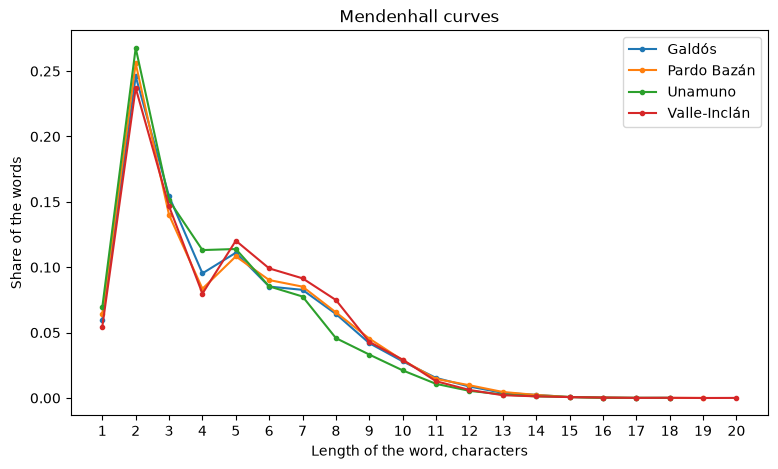

,Galdós,Pardo Bazán,Unamuno,Valle-Inclán
Galdós,0.000,0.030,0.062,0.048
Blasco Ibáñez,0.038,0.041,0.093,0.040
Palacio Valdés,0.020,0.023,0.068,0.041
Pardo Bazán,0.030,0.000,0.074,0.047
Pereda,0.036,0.049,0.038,0.065
Unamuno,0.062,0.074,0.000,0.089
Valera,0.041,0.045,0.059,0.068
Valle-Inclán,0.048,0.047,0.089,0.000
Clarín,0.024,0.030,0.070,0.037
Payró,0.026,0.036,0.060,0.061


In [15]:
chosen = ["Galdós", "Pardo Bazán", "Unamuno", "Valle-Inclán"]
fig, ax = plt.subplots(figsize=(9, 5))
mendenhall_plot({author: equal_samples[author] for author in chosen}, ax=ax)
ax.set_xticks(range(1, 21))
plt.show()
pd.DataFrame(
    {
        a: {b: mendenhall_distance(equal_samples[a], equal_samples[b]) for b in equal_samples}
        for a in chosen
    }
).round(3)

The curves nearly coincide: for all four authors about a quarter of the words have two letters. The visible differences are small: Unamuno has more words of four letters and fewer of eight and nine, Valle-Inclán more of five to eight. All the distances are below 0.1 on a scale up to 1: Galdós is 0.020 from Palacio Valdés and 0.030 from Pardo Bazán, and the largest values are in the column of Unamuno (up to 0.093 from Blasco Ibáñez), though he is close to Pereda (0.038). Word length alone tells few of these authors apart.

## Summary

- The old accents of the editions (57 of 93 works) are a signal of their own: with them the nearest work shares its spelling in 0.645-0.731 of the cases, without them in 0.516-0.602, near the 0.520 of chance. Removing them makes the nearest work more often one by the same author at 100 words and changes little either way at 200-500.
- On samples of about 10,000 words, Cosine Delta over 200-500 words finds a work of the same author as the nearest one for 0.914-0.925 of the works; in the dendrogram seven of ten authors form clusters of their own, while Galdós, Pereda and Payró mix.
- The profiles of the authors attribute 9 of the 10 latest works and 84 of 93 works in leave-one-out (90.3%); the errors gather on Payró (0 of 3), whose profile rests on two works, and Galdós (18 of 21).
- Both the dendrogram and the scaling split the authors into Blasco Ibáñez, Valle-Inclán, Clarín and Pardo Bazán on one side and Galdós, Unamuno, Pereda, Payró and Valera on the other.
- Zeta sets Galdós's abbreviations, words of speech and society and subjunctive in *-ra* against Pardo Bazán's words of physical description and her subjunctive in *-se*; by Kilgarriff's chi-square they are each other's nearest author.
- Galdós and Blasco Ibáñez differ in 45 features by both the effect and the bootstrap over works, above all in the morphology of narration: present tense, first person and pronouns against nouns, articles and the imperfect.
- Word length hardly separates the authors (all Mendenhall distances below 0.1).

The samples are the openings of the works, and the results hold for this corpus and these editions.